In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


In [3]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Dataset Shape :", X.shape)
print("Target Classes :", np.unique(y))


Dataset Shape : (569, 30)
Target Classes : [0 1]


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:

print("LOGISTIC REGRESSION")


lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [37]:

print("RANDOM FOREST")


rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))


RANDOM FOREST
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [19]:
print("GRADIENT BOOSTING")


gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print(classification_report(y_test, y_pred_gb))


GRADIENT BOOSTING
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [21]:
print("GRID SEARCH")


param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [3, 5, 7]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Best Parameters :", grid.best_params_)
print("Best CV Score :", grid.best_score_)

best_rf = grid.best_estimator_

best_pred = best_rf.predict(X_test)



GRID SEARCH
Best Parameters : {'max_depth': 5, 'n_estimators': 100}
Best CV Score : 0.953831183920065


In [25]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "Optimized Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, best_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb),
        precision_score(y_test, best_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb),
        recall_score(y_test, best_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb),
        f1_score(y_test, best_pred)
    ]
})


print("MODEL COMPARISON")


print(results)



MODEL COMPARISON
                     Model  Accuracy  Precision    Recall  F1 Score
0      Logistic Regression  0.982456   0.986111  0.986111  0.986111
1            Random Forest  0.956140   0.958904  0.972222  0.965517
2        Gradient Boosting  0.956140   0.946667  0.986111  0.965986
3  Optimized Random Forest  0.956140   0.958904  0.972222  0.965517


In [27]:
best_model = results.loc[results["Accuracy"].idxmax()]


print("FINAL MODEL")


print(best_model)


FINAL MODEL
Model        Logistic Regression
Accuracy                0.982456
Precision               0.986111
Recall                  0.986111
F1 Score                0.986111
Name: 0, dtype: object


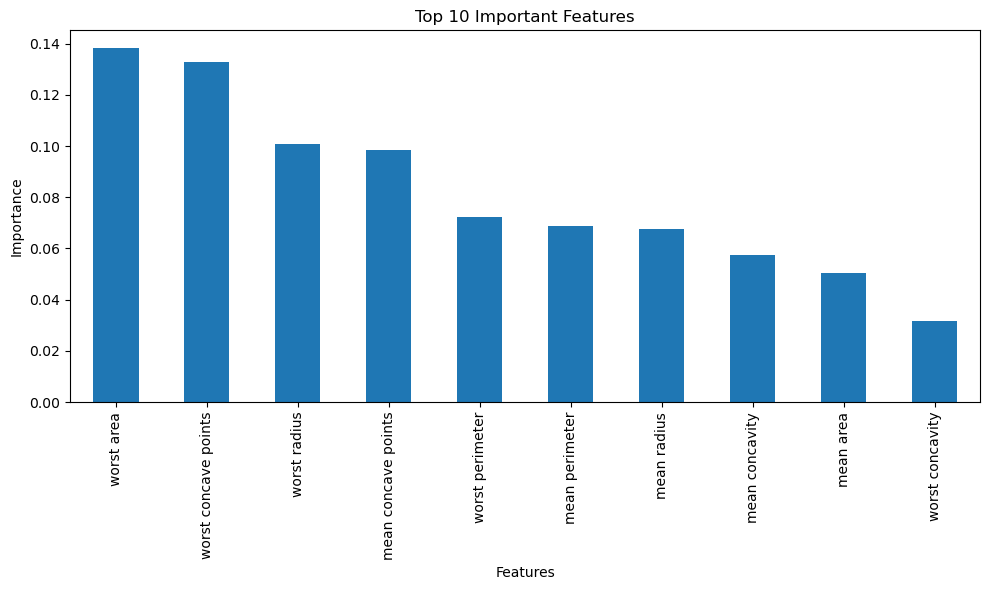

In [29]:
importance = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))

importance.head(10).plot(kind="bar")

plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.tight_layout()
plt.show()

In [31]:
cm = confusion_matrix(y_test, best_pred)

print("\nConfusion Matrix")

print(cm)



Confusion Matrix
[[39  3]
 [ 2 70]]
